In [2]:
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', '--break-system-packages'], 
               capture_output=True)
print("imbalanced-learn installed")

imbalanced-learn installed


In [3]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import pickle
import os

from src.features import load_features
from src.models import evaluate_model, save_model, save_metrics, run_all_visualizations

In [4]:
subjects      = ['A01T', 'A02T', 'A03T', 'A04T', 'A05T', 'A06T', 'A07T', 'A08T', 'A09T']
FEATURES_PATH = '../data/features/'
MODELS_PATH   = '../results/models/improved/'
METRICS_PATH  = '../results/metrics/improved/'
FIGURES_PATH  = '../results/figures/training/improved/'
CLASS_NAMES   = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

os.makedirs(MODELS_PATH,  exist_ok=True)
os.makedirs(METRICS_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)

In [5]:
# Load baseline results for comparison later
baseline_results = {}

for subject_id in subjects:
    baseline_results[subject_id] = {}
    for model_name in ['SVM', 'LDA', 'RF']:
        path = f'../results/models/baseline/{subject_id}_{model_name}.pkl'
        with open(path, 'rb') as f:
            model = pickle.load(f)
        baseline_results[subject_id][model_name] = model

print("Baseline models loaded successfully")

Baseline models loaded successfully


In [6]:
def tune_svm(X, y):
    param_grid = {
        'C':     [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.001, 0.01, 0.1]
    }
    svm = SVC(kernel='rbf', class_weight='balanced',
              probability=True, random_state=42)
    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    grid = GridSearchCV(svm, param_grid, cv=cv,
                        scoring='accuracy', n_jobs=-1, verbose=0)
    grid.fit(X, y)
    print(f"  Best SVM params: {grid.best_params_}")
    print(f"  Best CV score:   {grid.best_score_*100:.1f}%")
    return grid.best_estimator_


def build_ensemble():
    return VotingClassifier(
        estimators=[
            ('svm', SVC(kernel='rbf', class_weight='balanced',
                        probability=True, random_state=42)),
            ('lda', LinearDiscriminantAnalysis(solver='lsqr',
                                               shrinkage='auto')),
            ('rf',  RandomForestClassifier(n_estimators=200,
                                           class_weight='balanced',
                                           random_state=42))
        ],
        voting='soft'
    )


def apply_smote(X, y):
    print(f"  Before SMOTE: {np.bincount(y)}")
    sm = SMOTE(random_state=42, k_neighbors=3)
    X_bal, y_bal = sm.fit_resample(X, y)
    print(f"  After SMOTE:  {np.bincount(y_bal)}")
    return X_bal, y_bal

print("Improvement functions defined")

Improvement functions defined


In [7]:
# Train improved models on all subjects

improved_results = {}

for subject_id in subjects:
    print(f"\n{'='*50}")
    print(f"  {subject_id}")
    print(f"{'='*50}")

    X, y = load_features(subject_id, load_path=FEATURES_PATH)

    # Apply SMOTE to balance classes
    print("\n  Applying SMOTE...")
    X_bal, y_bal = apply_smote(X, y)

    improved_results[subject_id] = {}

    # Tuned SVM
    print("\n  Tuning SVM...")
    svm_tuned = tune_svm(X_bal, y_bal)
    result_svm = evaluate_model(svm_tuned, X_bal, y_bal)
    print(f"  Tuned SVM accuracy: {result_svm['mean']*100:.1f}% (+/- {result_svm['std']*100:.1f}%)")
    svm_tuned.fit(X_bal, y_bal)
    save_model(svm_tuned, subject_id, 'SVM_tuned', save_path=MODELS_PATH)
    improved_results[subject_id]['SVM_tuned'] = result_svm

    # LDA
    print("\n  Training LDA...")
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
    result_lda = evaluate_model(lda, X_bal, y_bal)
    print(f"  LDA accuracy: {result_lda['mean']*100:.1f}% (+/- {result_lda['std']*100:.1f}%)")
    lda.fit(X_bal, y_bal)
    save_model(lda, subject_id, 'LDA_improved', save_path=MODELS_PATH)
    improved_results[subject_id]['LDA_improved'] = result_lda

    # RF
    print("\n  Training RF...")
    rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
    result_rf = evaluate_model(rf, X_bal, y_bal)
    print(f"  RF accuracy: {result_rf['mean']*100:.1f}% (+/- {result_rf['std']*100:.1f}%)")
    rf.fit(X_bal, y_bal)
    save_model(rf, subject_id, 'RF_improved', save_path=MODELS_PATH)
    improved_results[subject_id]['RF_improved'] = result_rf

    # Ensemble
    print("\n  Training Ensemble...")
    ensemble = build_ensemble()
    result_ens = evaluate_model(ensemble, X_bal, y_bal)
    print(f"  Ensemble accuracy: {result_ens['mean']*100:.1f}% (+/- {result_ens['std']*100:.1f}%)")
    ensemble.fit(X_bal, y_bal)
    save_model(ensemble, subject_id, 'Ensemble', save_path=MODELS_PATH)
    improved_results[subject_id]['Ensemble'] = result_ens

print("\nAll subjects done.")


  A01T
Loaded features for A01T: X=(164, 8), y=(164,)

  Applying SMOTE...
  Before SMOTE: [44 61 33 26]
  After SMOTE:  [61 61 61 61]

  Tuning SVM...
  Best SVM params: {'C': 100, 'gamma': 'scale'}
  Best CV score:   89.8%
  Tuned SVM accuracy: 89.8% (+/- 3.6%)
Model saved to ../results/models/improved/A01T_SVM_tuned.pkl

  Training LDA...
  LDA accuracy: 83.6% (+/- 4.9%)
Model saved to ../results/models/improved/A01T_LDA_improved.pkl

  Training RF...
  RF accuracy: 87.3% (+/- 4.0%)
Model saved to ../results/models/improved/A01T_RF_improved.pkl

  Training Ensemble...
  Ensemble accuracy: 88.9% (+/- 3.1%)
Model saved to ../results/models/improved/A01T_Ensemble.pkl

  A02T
Loaded features for A02T: X=(216, 8), y=(216,)

  Applying SMOTE...
  Before SMOTE: [55 56 49 56]
  After SMOTE:  [56 56 56 56]

  Tuning SVM...
  Best SVM params: {'C': 1, 'gamma': 0.1}
  Best CV score:   63.4%
  Tuned SVM accuracy: 63.4% (+/- 6.2%)
Model saved to ../results/models/improved/A02T_SVM_tuned.pkl

  

In [8]:
# Accuracy summary — improved models

print("IMPROVED MODEL ACCURACY SUMMARY")
print("="*80)

rows = []
for subject_id in subjects:
    row = {'Subject': subject_id}
    for model_name in ['SVM_tuned', 'LDA_improved', 'RF_improved', 'Ensemble']:
        mean = improved_results[subject_id][model_name]['mean']
        std  = improved_results[subject_id][model_name]['std']
        row[model_name] = f"{mean*100:.1f}% (+/-{std*100:.1f}%)"
    rows.append(row)

improved_df = pd.DataFrame(rows)
print(improved_df.to_string(index=False))

print()
print("AVERAGE ACROSS ALL SUBJECTS")
print("-"*40)
for model_name in ['SVM_tuned', 'LDA_improved', 'RF_improved', 'Ensemble']:
    avg = np.mean([improved_results[s][model_name]['mean'] for s in subjects])
    std = np.std([improved_results[s][model_name]['mean'] for s in subjects])
    print(f"  {model_name}: {avg*100:.1f}% (+/- {std*100:.1f}%)")

improved_df.to_csv(f'{METRICS_PATH}improved_accuracy_summary.csv', index=False)

IMPROVED MODEL ACCURACY SUMMARY
Subject       SVM_tuned    LDA_improved      RF_improved        Ensemble
   A01T 89.8% (+/-3.6%) 83.6% (+/-4.9%)  87.3% (+/-4.0%) 88.9% (+/-3.1%)
   A02T 63.4% (+/-6.2%) 61.6% (+/-6.0%)  61.2% (+/-6.9%) 65.2% (+/-5.2%)
   A03T 91.7% (+/-2.5%) 87.7% (+/-4.9%)  91.7% (+/-1.2%) 91.2% (+/-3.0%)
   A04T 58.1% (+/-6.9%) 57.7% (+/-4.3%)  57.0% (+/-3.2%) 55.9% (+/-3.1%)
   A05T 70.3% (+/-5.2%) 58.9% (+/-3.6%)  69.1% (+/-9.6%) 69.6% (+/-7.6%)
   A06T 54.5% (+/-5.7%) 54.1% (+/-6.5%)  52.1% (+/-2.4%) 55.2% (+/-4.2%)
   A07T 84.0% (+/-8.1%) 84.0% (+/-5.4%) 75.0% (+/-12.6%) 82.7% (+/-5.9%)
   A08T 90.2% (+/-2.9%) 88.8% (+/-4.2%)  87.3% (+/-3.2%) 89.9% (+/-3.7%)
   A09T 64.6% (+/-6.7%) 66.1% (+/-5.3%)  66.6% (+/-3.7%) 68.2% (+/-6.1%)

AVERAGE ACROSS ALL SUBJECTS
----------------------------------------
  SVM_tuned: 74.1% (+/- 14.0%)
  LDA_improved: 71.4% (+/- 13.5%)
  RF_improved: 71.9% (+/- 13.5%)
  Ensemble: 74.1% (+/- 13.6%)


In [9]:
# Side by side comparison — baseline vs improved (SVM vs SVM_tuned)

print("BASELINE vs IMPROVED COMPARISON (SVM)")
print("="*60)

comparison_rows = []
for subject_id in subjects:
    # Load baseline accuracy from saved CSV
    baseline_csv = pd.read_csv('../results/metrics/baseline/accuracy_summary.csv')
    baseline_row = baseline_csv[baseline_csv['Subject'] == subject_id].iloc[0]
    baseline_acc = baseline_row['SVM_mean']

    improved_acc = improved_results[subject_id]['SVM_tuned']['mean'] * 100
    diff         = improved_acc - baseline_acc

    comparison_rows.append({
        'Subject':      subject_id,
        'Baseline SVM': f"{baseline_acc:.1f}%",
        'Tuned SVM':    f"{improved_acc:.1f}%",
        'Improvement':  f"+{diff:.1f}%" if diff >= 0 else f"{diff:.1f}%"
    })
    print(f"  {subject_id}: {baseline_acc:.1f}% -> {improved_acc:.1f}% ({'+' if diff>=0 else ''}{diff:.1f}%)")

comp_df = pd.DataFrame(comparison_rows)
comp_df.to_csv(f'{METRICS_PATH}baseline_vs_improved.csv', index=False)

BASELINE vs IMPROVED COMPARISON (SVM)
  A01T: 84.2% -> 89.8% (+5.6%)
  A02T: 58.8% -> 63.4% (+4.6%)
  A03T: 87.7% -> 91.7% (+4.0%)
  A04T: 55.4% -> 58.1% (+2.7%)
  A05T: 54.3% -> 70.3% (+16.0%)
  A06T: 53.6% -> 54.5% (+0.9%)
  A07T: 82.2% -> 84.0% (+1.9%)
  A08T: 87.2% -> 90.2% (+3.1%)
  A09T: 62.6% -> 64.6% (+2.0%)


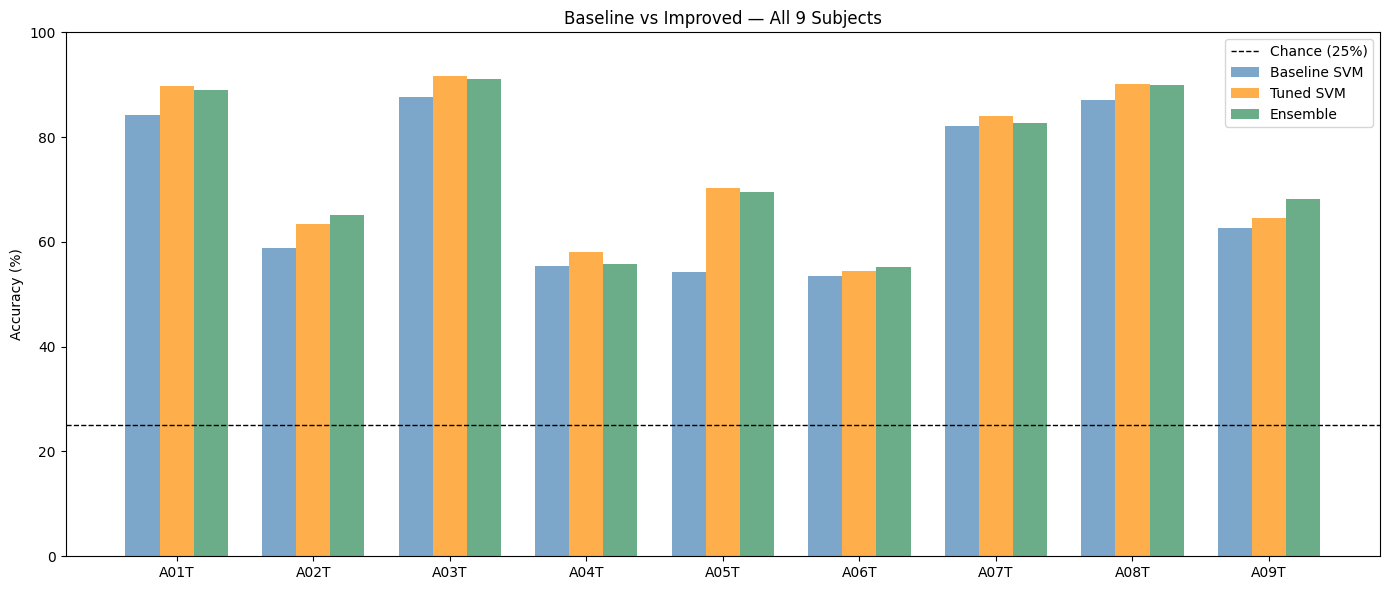

In [10]:
# Visual comparison — baseline vs improved

baseline_csv  = pd.read_csv('../results/metrics/baseline/accuracy_summary.csv')
baseline_svm  = baseline_csv['SVM_mean'].values
improved_svm  = [improved_results[s]['SVM_tuned']['mean'] * 100 for s in subjects]
improved_ens  = [improved_results[s]['Ensemble']['mean']  * 100 for s in subjects]

x     = np.arange(len(subjects))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, baseline_svm, width, label='Baseline SVM',  color='steelblue', alpha=0.7)
ax.bar(x,         improved_svm, width, label='Tuned SVM',     color='darkorange', alpha=0.7)
ax.bar(x + width, improved_ens, width, label='Ensemble',      color='seagreen',   alpha=0.7)

ax.axhline(y=25,  color='black', linestyle='--', linewidth=1, label='Chance (25%)')
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Baseline vs Improved — All 9 Subjects')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}baseline_vs_improved_comparison.png', dpi=100)
plt.show()

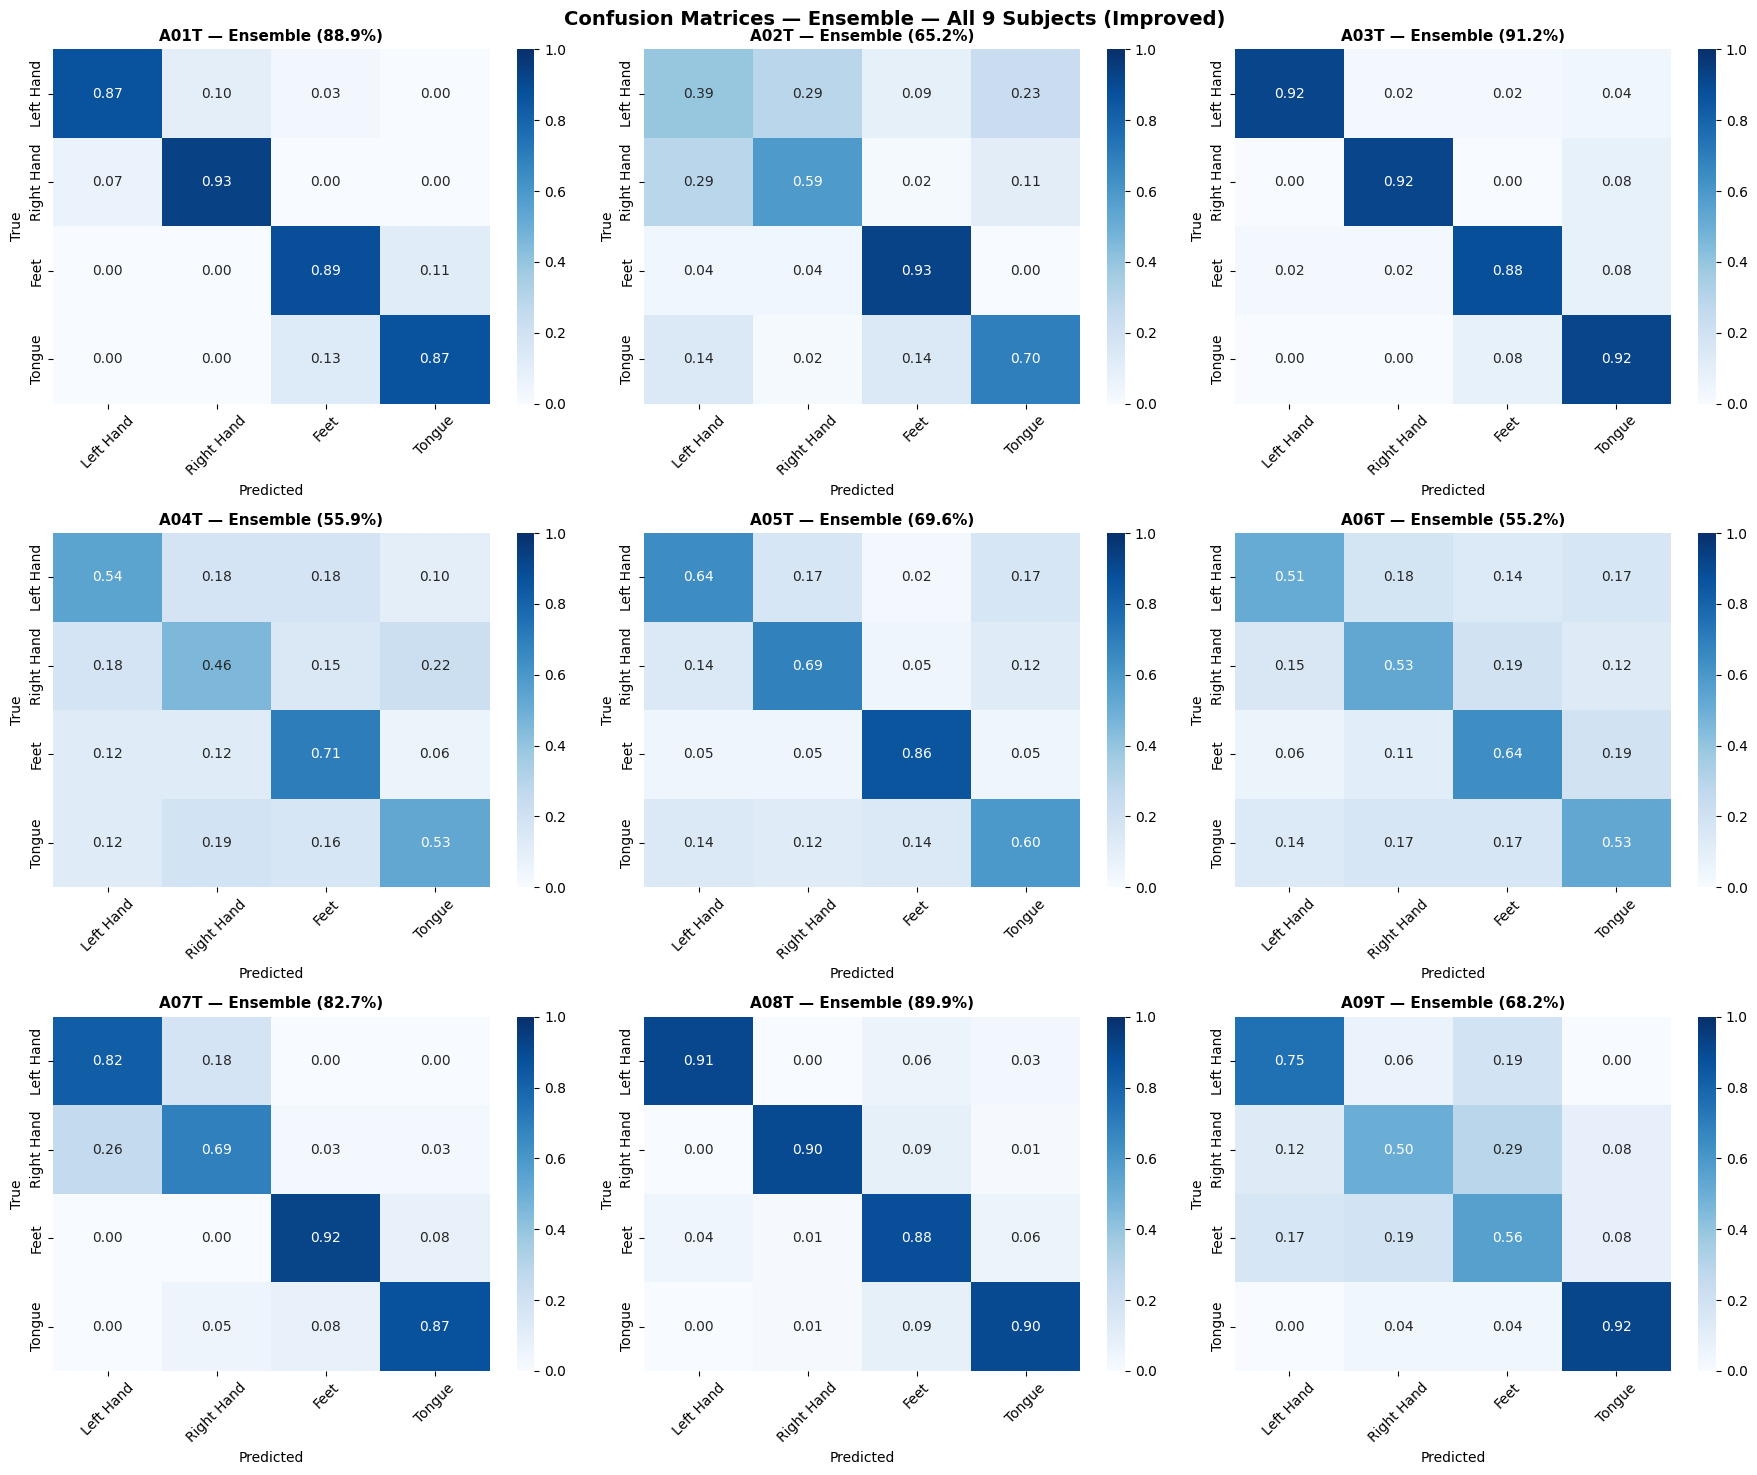

In [11]:
# Confusion matrices for best improved model (Ensemble) — all subjects

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, subject_id in zip(axes.flat, subjects):
    cm      = improved_results[subject_id]['Ensemble']['cm']
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
        vmin=0, vmax=1
    )
    acc = improved_results[subject_id]['Ensemble']['mean'] * 100
    ax.set_title(f"{subject_id} — Ensemble ({acc:.1f}%)", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Ensemble — All 9 Subjects (Improved)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}confusion_matrices_ensemble_improved.png', dpi=100)
plt.show()

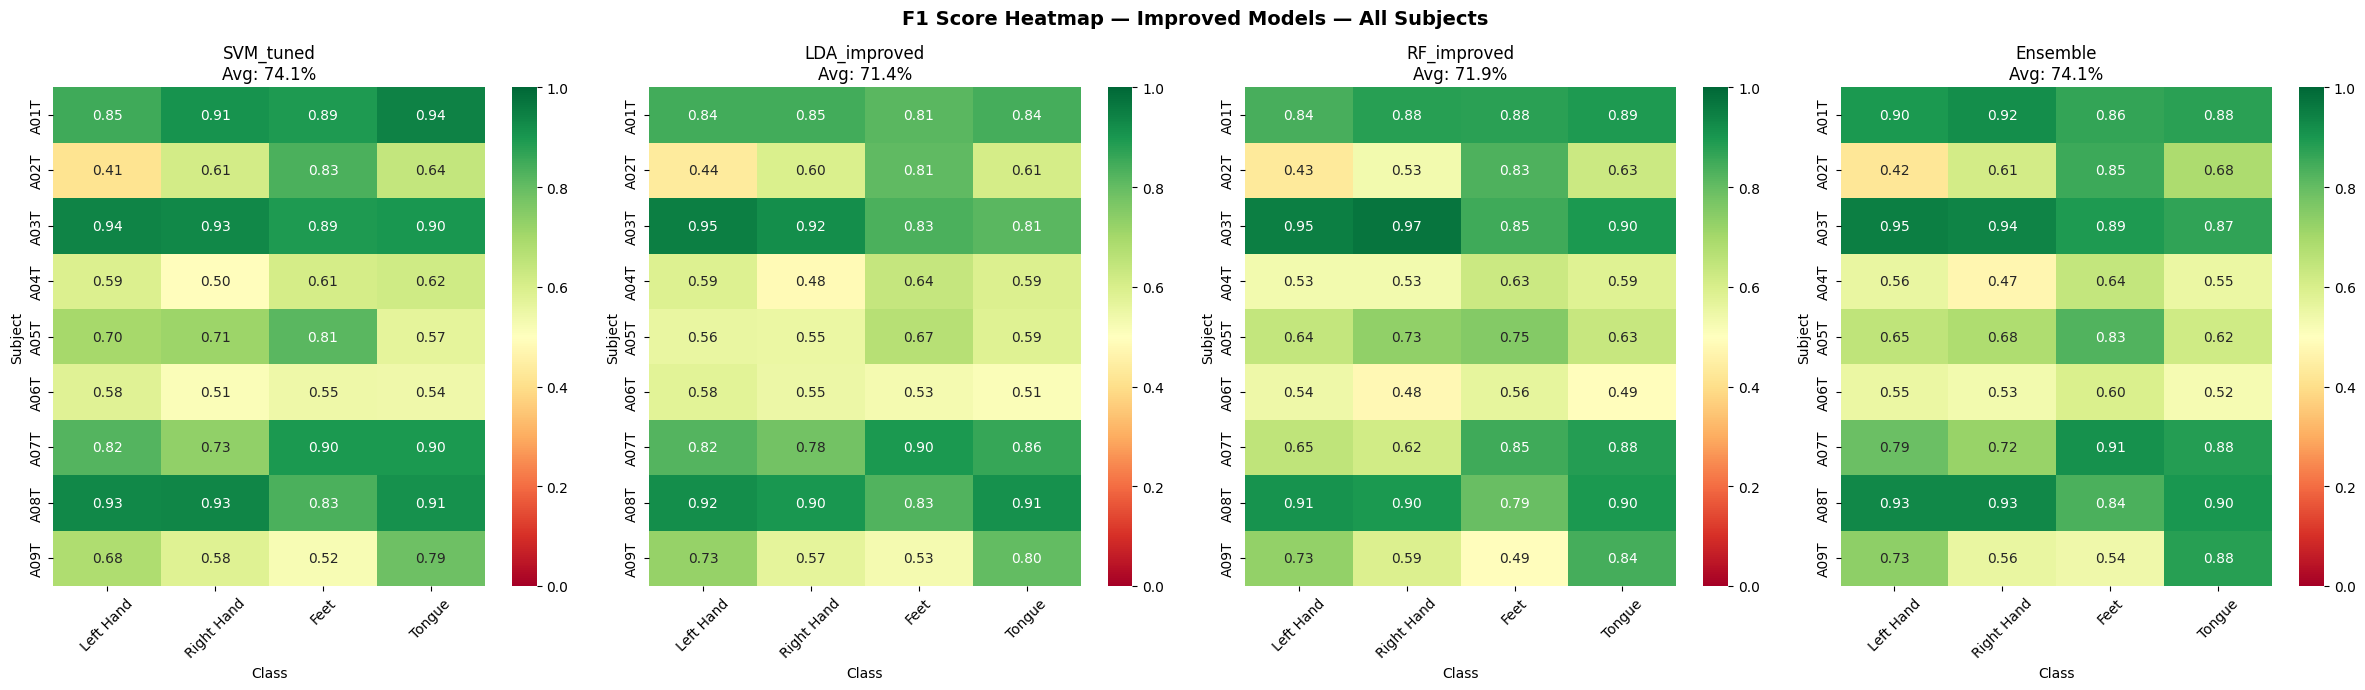

In [12]:
# F1 heatmap for improved models

fig, axes = plt.subplots(1, 4, figsize=(24, 7))

for ax, model_name in zip(axes, ['SVM_tuned', 'LDA_improved', 'RF_improved', 'Ensemble']):
    f1_matrix = []
    for subject_id in subjects:
        report = improved_results[subject_id][model_name]['report']
        f1_row = [report[cls]['f1-score'] for cls in CLASS_NAMES]
        f1_matrix.append(f1_row)

    sns.heatmap(
        np.array(f1_matrix),
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        xticklabels=CLASS_NAMES,
        yticklabels=subjects,
        ax=ax,
        vmin=0, vmax=1
    )
    avg = np.mean([improved_results[s][model_name]['mean'] for s in subjects])
    ax.set_title(f'{model_name}\nAvg: {avg*100:.1f}%')
    ax.set_xlabel('Class')
    ax.set_ylabel('Subject')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('F1 Score Heatmap — Improved Models — All Subjects',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}f1_heatmap_improved.png', dpi=100)
plt.show()